# CIFAR-10 Linear Classification

This notebook implements and trains a linear classifier on the CIFAR-10 dataset. Each image is converted into a `32 x 32 x 3 = 3072`-dimensional vector, and multiclass classification is performed with softmax cross-entropy loss.

The linear classifier learns one weight vector for each class and computes class scores using the dot product between the input image and the weights.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

RESULT_DIR = Path('results')
RESULT_DIR.mkdir(exist_ok=True)

CIFAR10_LABELS = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

## 1. Load and Preprocess Data

In [2]:
import pickle
import tarfile
import urllib.request

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
CIFAR10_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
CIFAR10_ARCHIVE = DATA_DIR / 'cifar-10-python.tar.gz'
CIFAR10_DIR = DATA_DIR / 'cifar-10-batches-py'

if not CIFAR10_DIR.exists():
    if not CIFAR10_ARCHIVE.exists():
        print('Downloading CIFAR-10...')
        urllib.request.urlretrieve(CIFAR10_URL, CIFAR10_ARCHIVE)
    with tarfile.open(CIFAR10_ARCHIVE, 'r:gz') as tar:
        tar.extractall(DATA_DIR)

def load_cifar_batch(path):
    with open(path, 'rb') as file:
        batch = pickle.load(file, encoding='latin1')
    images = batch['data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch['labels'])
    return images, labels

train_images = []
train_labels = []
for batch_idx in range(1, 6):
    images, labels = load_cifar_batch(CIFAR10_DIR / f'data_batch_{batch_idx}')
    train_images.append(images)
    train_labels.append(labels)

x_train = np.concatenate(train_images)
y_train = np.concatenate(train_labels)
x_test, y_test = load_cifar_batch(CIFAR10_DIR / 'test_batch')
y_train = y_train.ravel()
y_test = y_test.ravel()

print('Train:', x_train.shape, y_train.shape)
print('Test :', x_test.shape, y_test.shape)

Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


In [3]:
TRAIN_LIMIT = 5000
TEST_LIMIT = 1000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)
train_idx = rng.choice(len(x_train), size=TRAIN_LIMIT, replace=False)
test_idx = rng.choice(len(x_test), size=TEST_LIMIT, replace=False)

x_train_small = x_train[train_idx]
y_train_small = y_train[train_idx]
x_test_small = x_test[test_idx]
y_test_small = y_test[test_idx]

X_train = x_train_small.reshape(TRAIN_LIMIT, -1).astype(np.float32) / 255.0
X_test = x_test_small.reshape(TEST_LIMIT, -1).astype(np.float32) / 255.0

# Subtracting the mean image makes gradient descent more stable.
mean_image = X_train.mean(axis=0, keepdims=True)
X_train_centered = X_train - mean_image
X_test_centered = X_test - mean_image

print('Flattened train:', X_train_centered.shape)
print('Flattened test :', X_test_centered.shape)

Flattened train: (5000, 3072)
Flattened test : (1000, 3072)


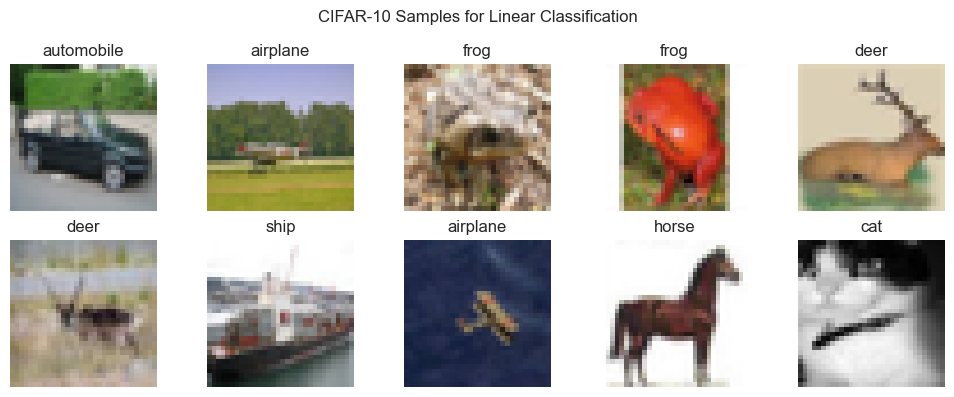

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), x_train_small[:10], y_train_small[:10]):
    ax.imshow(image)
    ax.set_title(CIFAR10_LABELS[label])
    ax.axis('off')
fig.suptitle('CIFAR-10 Samples for Linear Classification')
fig.tight_layout()
fig.savefig(RESULT_DIR / '6_cifar10_linear_samples.png', dpi=150)
plt.show()

## 2. Implement the Softmax Linear Classifier

In [5]:
def linear_scores(X, W, b):
    return X @ W + b


def softmax_loss_and_grad(X, y, W, b, reg_strength):
    num_samples = X.shape[0]
    scores = linear_scores(X, W, b)
    scores -= scores.max(axis=1, keepdims=True)

    exp_scores = np.exp(scores)
    probabilities = exp_scores / exp_scores.sum(axis=1, keepdims=True)

    correct_log_probs = -np.log(probabilities[np.arange(num_samples), y] + 1e-12)
    data_loss = correct_log_probs.mean()
    reg_loss = 0.5 * reg_strength * np.sum(W * W)
    loss = data_loss + reg_loss

    dscores = probabilities
    dscores[np.arange(num_samples), y] -= 1.0
    dscores /= num_samples

    dW = X.T @ dscores + reg_strength * W
    db = dscores.sum(axis=0)
    return loss, dW, db


def predict_linear_classifier(X, W, b):
    return np.argmax(linear_scores(X, W, b), axis=1)


def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)


def train_linear_classifier(
    X_train, y_train, X_test, y_test,
    learning_rate=0.2, reg_strength=1e-4,
    num_iters=800, batch_size=256, random_seed=42,
):
    rng = np.random.default_rng(random_seed)
    num_features = X_train.shape[1]
    num_classes = 10

    W = 0.001 * rng.standard_normal((num_features, num_classes), dtype=np.float32)
    b = np.zeros(num_classes, dtype=np.float32)
    history = {'loss': [], 'train_acc': [], 'test_acc': [], 'iter': []}

    start_time = perf_counter()
    for step in range(1, num_iters + 1):
        batch_idx = rng.choice(len(X_train), size=batch_size, replace=False)
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]

        loss, dW, db = softmax_loss_and_grad(X_batch, y_batch, W, b, reg_strength)
        W -= learning_rate * dW
        b -= learning_rate * db

        if step == 1 or step % 100 == 0 or step == num_iters:
            train_pred = predict_linear_classifier(X_train, W, b)
            test_pred = predict_linear_classifier(X_test, W, b)
            train_acc = accuracy_score(y_train, train_pred)
            test_acc = accuracy_score(y_test, test_pred)

            history['loss'].append(loss)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            history['iter'].append(step)

            print(
                f'iter={step:4d}, loss={loss:.4f}, '
                f'train_acc={train_acc:.4f}, test_acc={test_acc:.4f}'
            )

    history['time_sec'] = perf_counter() - start_time
    return W, b, history

## 3. Train the Model

In [6]:
W, b, history = train_linear_classifier(
    X_train_centered,
    y_train_small,
    X_test_centered,
    y_test_small,
    learning_rate=0.2,
    reg_strength=1e-4,
    num_iters=800,
    batch_size=256,
    random_seed=RANDOM_SEED,
)

final_train_acc = history['train_acc'][-1]
final_test_acc = history['test_acc'][-1]
print(f'Final train accuracy: {final_train_acc:.4f}')
print(f'Final test accuracy : {final_test_acc:.4f}')
print(f'Training time       : {history["time_sec"]:.2f}s')

iter=   1, loss=2.3032, train_acc=0.2070, test_acc=0.2000
iter= 100, loss=1.5738, train_acc=0.4184, test_acc=0.3650


iter= 200, loss=1.6464, train_acc=0.4426, test_acc=0.3520
iter= 300, loss=1.5599, train_acc=0.4690, test_acc=0.3620


iter= 400, loss=1.4994, train_acc=0.4726, test_acc=0.3400
iter= 500, loss=1.5381, train_acc=0.5072, test_acc=0.3640


iter= 600, loss=1.5053, train_acc=0.5066, test_acc=0.3390
iter= 700, loss=1.4239, train_acc=0.5250, test_acc=0.3480


iter= 800, loss=1.5030, train_acc=0.5360, test_acc=0.3510
Final train accuracy: 0.5360
Final test accuracy : 0.3510
Training time       : 1.53s


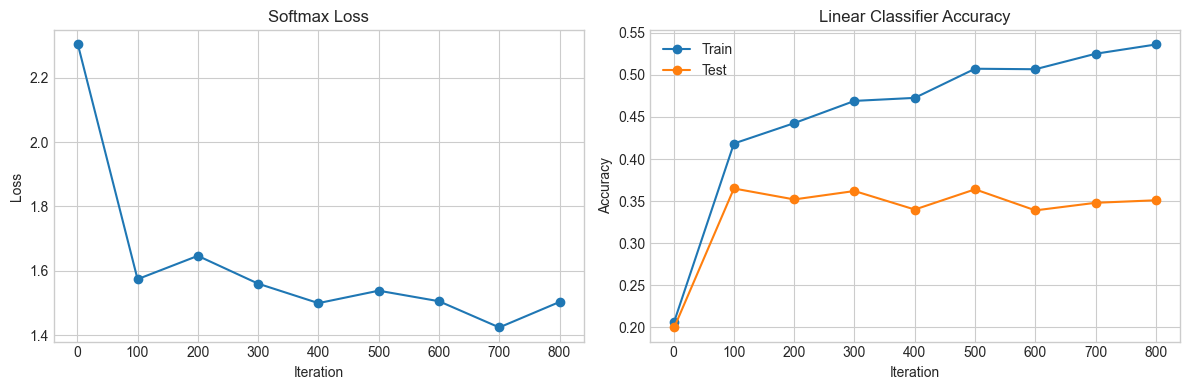

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['iter'], history['loss'], marker='o')
axes[0].set_title('Softmax Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')

axes[1].plot(history['iter'], history['train_acc'], marker='o', label='Train')
axes[1].plot(history['iter'], history['test_acc'], marker='o', label='Test')
axes[1].set_title('Linear Classifier Accuracy')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / '6_cifar10_linear_training_curves.png', dpi=150)
plt.show()

## 4. Visualize Class Weights

The weight vector of a linear classifier shows which pixel patterns are important for each class. The images below reshape each class weight vector back into a `32 x 32 x 3` image for visualization.

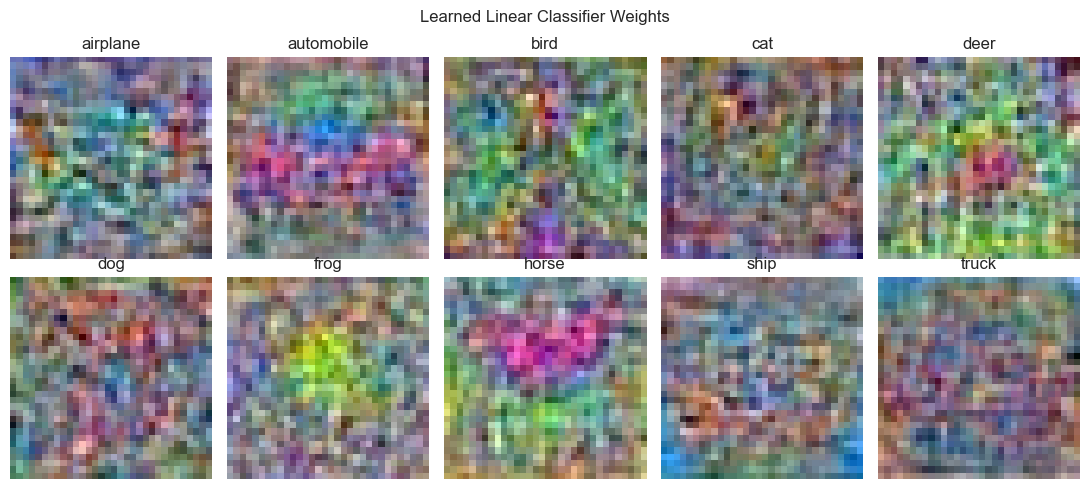

In [8]:
weight_images = W.reshape(32, 32, 3, 10)
fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for class_idx, ax in enumerate(axes.ravel()):
    weight_img = weight_images[:, :, :, class_idx]
    weight_img = (weight_img - weight_img.min()) / (weight_img.max() - weight_img.min() + 1e-12)
    ax.imshow(weight_img)
    ax.set_title(CIFAR10_LABELS[class_idx])
    ax.axis('off')

fig.suptitle('Learned Linear Classifier Weights')
fig.tight_layout()
fig.savefig(RESULT_DIR / '6_cifar10_linear_weights.png', dpi=150)
plt.show()

## 5. Visualize Linear Classification Decision Regions

The original CIFAR-10 images are 3072-dimensional, so their decision regions cannot be visualized directly. Here, the training data is projected to two dimensions with PCA, and a separate linear classifier is trained on that 2D plane to visualize the decision regions.

In [9]:
REGION_TRAIN_LIMIT = 1200
REGION_TEST_LIMIT = 400
REGION_SCATTER_LIMIT = 400
GRID_SIZE = 160

X_region_source = X_train_centered[:REGION_TRAIN_LIMIT]
y_region = y_train_small[:REGION_TRAIN_LIMIT]
X_region_test_source = X_test_centered[:REGION_TEST_LIMIT]
y_region_test = y_test_small[:REGION_TEST_LIMIT]

region_mean = X_region_source.mean(axis=0, keepdims=True)
X_region_centered = X_region_source - region_mean
_, _, vt = np.linalg.svd(X_region_centered, full_matrices=False)
components = vt[:2]

X_region_2d = X_region_centered @ components.T
X_region_test_2d = (X_region_test_source - region_mean) @ components.T

W_region, b_region, region_history = train_linear_classifier(
    X_region_2d.astype(np.float32),
    y_region,
    X_region_test_2d.astype(np.float32),
    y_region_test,
    learning_rate=0.1,
    reg_strength=1e-4,
    num_iters=600,
    batch_size=256,
    random_seed=RANDOM_SEED,
)

x_min, x_max = X_region_2d[:, 0].min() - 1.0, X_region_2d[:, 0].max() + 1.0
y_min, y_max = X_region_2d[:, 1].min() - 1.0, X_region_2d[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_SIZE),
    np.linspace(y_min, y_max, GRID_SIZE),
)
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
region_pred = predict_linear_classifier(grid_points, W_region, b_region).reshape(xx.shape)

iter=   1, loss=2.3030, train_acc=0.1842, test_acc=0.1700
iter= 100, loss=2.0978, train_acc=0.2142, test_acc=0.2050
iter= 200, loss=2.1589, train_acc=0.2042, test_acc=0.2075
iter= 300, loss=2.1386, train_acc=0.1925, test_acc=0.1750
iter= 400, loss=2.1257, train_acc=0.2050, test_acc=0.1825
iter= 500, loss=2.1980, train_acc=0.1900, test_acc=0.2075
iter= 600, loss=2.1198, train_acc=0.2025, test_acc=0.2150


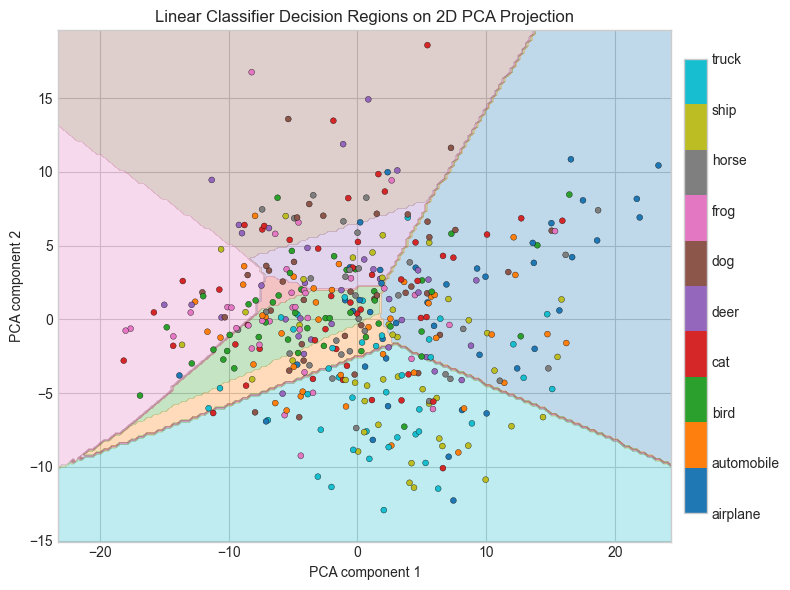

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap('tab10')
levels = np.arange(11) - 0.5

ax.contourf(xx, yy, region_pred, levels=levels, cmap=cmap, alpha=0.28)
scatter = ax.scatter(
    X_region_2d[:REGION_SCATTER_LIMIT, 0],
    X_region_2d[:REGION_SCATTER_LIMIT, 1],
    c=y_region[:REGION_SCATTER_LIMIT],
    cmap=cmap,
    s=18,
    edgecolors='k',
    linewidths=0.25,
)
ax.set_title('Linear Classifier Decision Regions on 2D PCA Projection')
ax.set_xlabel('PCA component 1')
ax.set_ylabel('PCA component 2')

cbar = fig.colorbar(scatter, ax=ax, ticks=np.arange(10), fraction=0.035, pad=0.02)
cbar.ax.set_yticklabels(CIFAR10_LABELS)
fig.tight_layout()
fig.savefig(RESULT_DIR / '6_cifar10_linear_decision_regions.png', dpi=150)
plt.show()

## 6. Analysis

- The linear classifier computes scores using the dot product between the input image and the class-specific weights.
- The softmax function converts class scores into probability-like values, and cross-entropy loss encourages the probability of the correct class to increase.
- KNN stores the training data and searches for nearby examples at test time, while the linear classifier learns parameters `W` and `b` during training and predicts with a single matrix multiplication at test time.
- For complex images such as CIFAR-10, simple linear boundaries cannot separate all classes accurately, but the training curves and weight images show what patterns the classifier learns.
- The decision region plot comes from a separate linear classifier trained in 2D PCA space, so it is not identical to the original 3072-dimensional classification result, but it gives an intuitive view of how linear classification boundaries divide the space.